# Diagnóstico y limpieza del integrado UK Property (precio + geo)

Cuaderno de diagnóstico y limpieza (nulos, duplicados y outliers) sobre `db/uk_property_price.csv`.

**Foco del diagnóstico:** `price`, `latitude`, `longitude`, `town_city`, `county`, `country`.

Metodología (`presentacion.html` y `codigo/limpieza_telecom.py` del curso): diagnóstico con `isna()`/`duplicated()`/`describe()`, clasificación de faltantes **MCAR / MAR / MNAR**, detección de atípicos con **regla IQR (Tukey)** y decisión **tratar vs conservar** según negocio (winsorizar).

Orden canónico: `DIAGNÓSTICO → DUPLICADOS → CATEGORÍAS → FALTANTES → OUTLIERS → VALIDACIÓN → EXPORTAR`. El original nunca se modifica; toda decisión queda en bitácora.

## 1. Objetivo

Preparar las 6 columnas analíticas del integrado para su uso en el proyecto (series de tiempo y modelado posterior):

- `price` — variable objetivo (GBP): atípicos vía **IQR (Tukey)** → winsorizar + bandera.
- `latitude` / `longitude` — georreferenciación: nulos clasificados (MCAR/MAR/MNAR), rangos válidos.
- `town_city` / `county` / `country` — categorías: cardinalidad, escrituras, colisiones.

Todo el procesamiento se ejecuta con funciones del paquete `script/limpieza` (config, diag, transformaciones, validación, gráficas): la lógica vive una sola vez.

## 2. Preparación

Se resuelve la raíz del proyecto y se enlaza el paquete `limpieza` con sus constantes (las cifras verificadas del diagnóstico real) y sus funciones de análisis.

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# Raiz del proyecto: busca hacia arriba la carpeta db/ (o data/)
PROYECTO = Path.cwd()
while not any((PROYECTO / c).exists() for c in ['db', 'data']) and PROYECTO != PROYECTO.parent:
    PROYECTO = PROYECTO.parent

# Paquete de limpieza del proyecto: la logica vive una sola vez (modular)
sys.path.insert(0, str(PROYECTO / 'script'))
import limpieza
from limpieza import config
from limpieza.cargar import cargar_dataset, hallar_csv_origen
from limpieza import diagnostico as diag
from limpieza import transformaciones, validacion, graficos
from limpieza.bitacora import Bitacora

graficos.establecer_estilo()
print('raiz del proyecto:', PROYECTO.name)
print('paquete limpieza v' + limpieza.__version__, '· RUTA_ORIGEN:', config.RUTA_ORIGEN.relative_to(PROYECTO))

raiz del proyecto: mineria
paquete limpieza v1.0.0 · RUTA_ORIGEN: db\uk_property_price.csv


## 3. Carga del dataset

Mismos dtypes optimizados que `libros/Lectura.ipynb`.

In [2]:
df = cargar_dataset(config.RUTA_ORIGEN)

carga uk_property_price.csv OK en 126.2 s -> (11369413, 20)


## 4. Diagnóstico: las tres preguntas

Diagnóstico con tres preguntas: **¿cuánto falta?** (`isna`), **¿qué está repetido?** (`duplicated`) y **¿qué se sale de rango?** (`describe`), con foco en las 6 columnas analíticas.

In [3]:
display(diag.perfil_foco(df))
print('\nduplicados exactos:', int(df.duplicated().sum()))
print('duplicados por transaction_id:', int(df[config.CLAVE_PRIMARIA].duplicated().sum()))

,columna,tipo,nulos,nulos_%,unicos,min,max
0,price,int64,0,0.0,192588,100,900000000
1,latitude,float64,22913,0.2,2303,49.895165,55.768304
2,longitude,float64,22913,0.2,2303,-6.352711,1.740933
3,town_city,category,0,0.0,1153,-,-
4,county,category,0,0.0,117,-,-
5,country,category,22913,0.2,2,-,-



duplicados exactos: 0


duplicados por transaction_id: 0


In [4]:
print('describe de price (original, sin limpiar):')
display(df['price'].astype('float64').describe().round(1).to_frame('price'))

describe de price (original, sin limpiar):


,price
count,11369413.0
mean,364247.9
std,1521167.3
min,100.0
25%,158000.0
50%,250000.0
75%,385000.0
max,900000000.0


**Lectura del diagnóstico**

- `price`: 100 a **900.000.000** GBP → requiere IQR (§7).
- `latitude`/`longitude`: **22.913 nulos** (0,20 %) → clasificar como MCAR (§5).
- `town_city`: 1.153 municipios; `county`: 117; `country`: **2** (England/Wales).
- Duplicados exactos y por llave: **0** (la base ya viene única).

## 5. Valores faltantes: MCAR, MAR, MNAR

Para elegir la estrategia, la clave es el **origen** del faltante, no su cantidad.

| Tipo | Qué es | Acción en datos |
|---|---|---|
| **MCAR** | La ausencia no depende de nada medible (falló la geocodificación) | Imputar es seguro; o bandera |
| **MAR** | Depende de OTRA variable que sí observamos | Imputar condicionando por grupos |
| **MNAR** | Depende del propio valor que no vemos (lujo oculto) | Bandera y consultar al negocio |

En nuestro dataset **solo la geografía falta** (lat/lon/region/country/admin_district juntos) y siempre en las mismas 22.913 filas.

In [5]:
# 1) simultaneidad del faltante geo
geo = diag.nulos_geo(df)
print('con al menos una geo nula:', f"{geo['cualquiera']:,}")
print('con TODAS las geo nulas :', f"{geo['todas']:,}")
assert geo['simultaneo'], 'Los nulos geo NO son simultaneos'

# 2) evidencia MCAR: el price (observado) cambia poco con o sin geo
sin_geo = df['latitude'].isna()
print('\nmediana price · con geo :', f"{df.loc[~sin_geo, 'price'].median():,.0f}")
print('mediana price · sin geo :', f"{df.loc[sin_geo, 'price'].median():,.0f}")
tasa = (df.groupby(df[config.COLUMNA_FECHA].dt.year)['latitude']
        .apply(lambda s: s.isna().mean()).mul(100).round(3))
print('tasa de nulos geo por anio (%): media', round(float(tasa.mean()), 3))

con al menos una geo nula: 22,913
con TODAS las geo nulas : 22,913



mediana price · con geo : 250,000
mediana price · sin geo : 278,000


tasa de nulos geo por anio (%): media 0.198


**Interpretación**: el faltante geo es **MCAR**. La ausencia no está ligada al valor de `price` (medianas casi idénticas) ni crece por año (la tasa es estable, como muestra el gráfico). Aparece cuando el servicio de geocodificación no ubicó la propiedad.

**Estrategia elegida: bandera** `es_sin_geo` (método *constante/bandera*: “la ausencia significa algo”), **NO imputación** (inventar coordenadas falsearía un clustering espacial futuro) y **NO `dropna`**: aunque el 0,20 % con MCAR lo haría permisible (regla < 5 %), el `price` de esas filas sigue siendo válido.

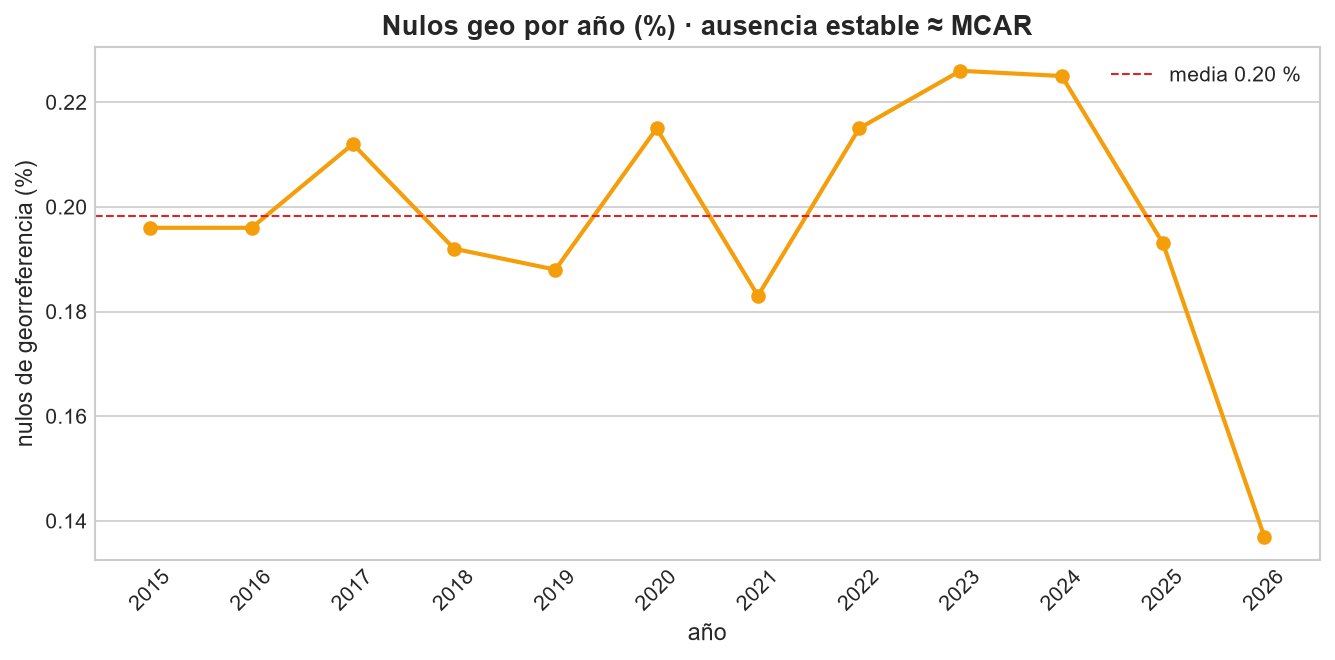

In [6]:
graficos.presentar(graficos.tasa_nulos_geo_por_anio(df))

## 6. Categorías: `town_city`, `county`, `country`

Cardinalidad, escrituras y colisiones tras normalizar (strip + mayúsculas), como en el caso TelecomUNO (16 escrituras → 5 ciudades reales).

In [7]:
display(diag.resumen_categorias(df))
colisiones = diag.colisiones_al_normalizar(df)
for col, info in colisiones.items():
    print(f"{col}: colisiones al normalizar = {info['colisiones']} · todo en mayusculas = {info['todo_en_mayusculas']}")

,columna,categorias,nulos
0,town_city,1153,0
1,county,117,0
2,country,2,22913


town_city: colisiones al normalizar = 0 · todo en mayusculas = True
county: colisiones al normalizar = 0 · todo en mayusculas = True
country: colisiones al normalizar = 0 · todo en mayusculas = False


**Lectura**: 0 colisiones y escritura consistente → las 3 categorías **ya están normalizadas** en la fuente; no requieren `replace` ni mapeos masivos (solo queda la verificación defensiva).

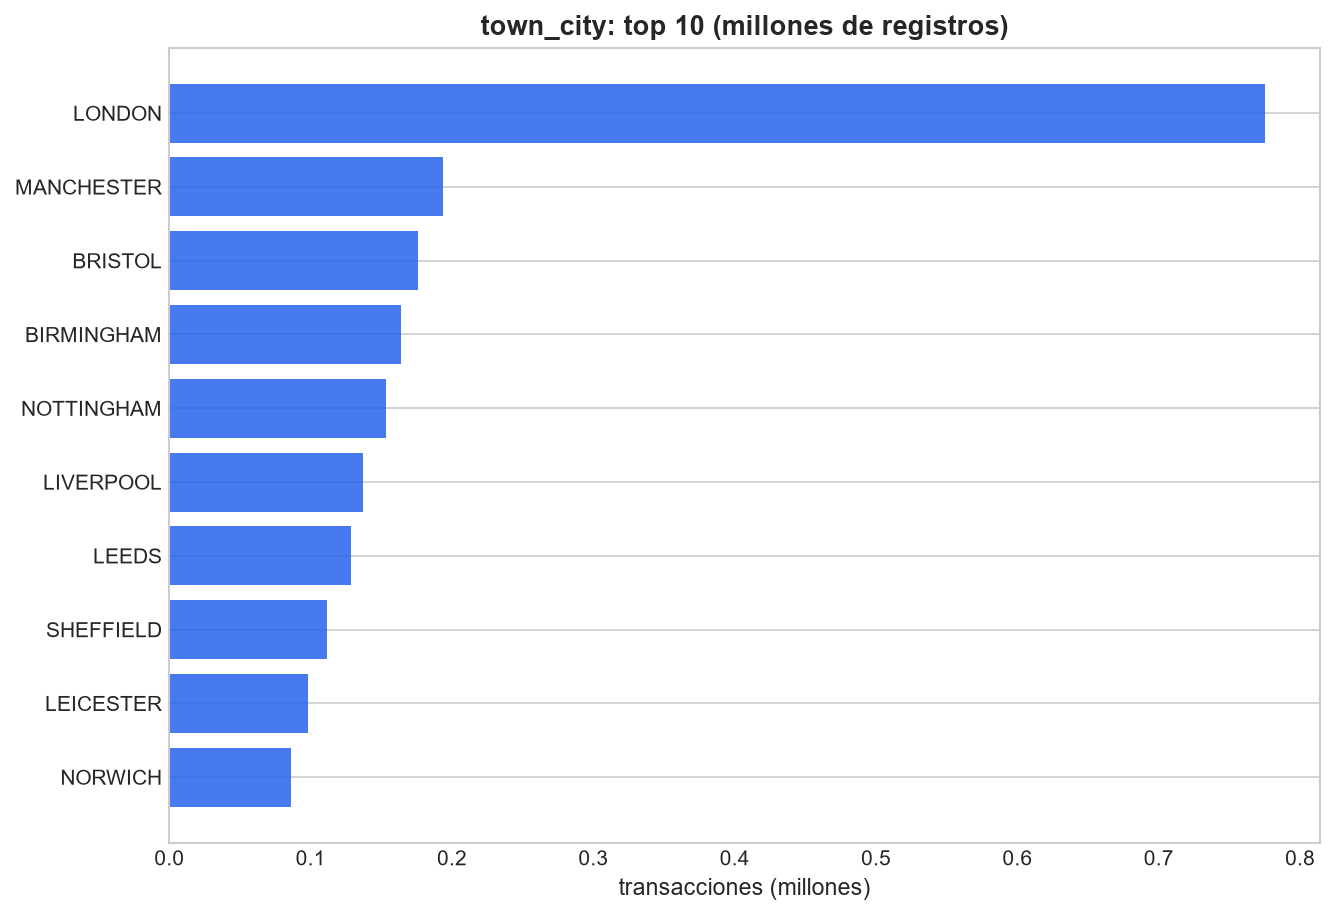

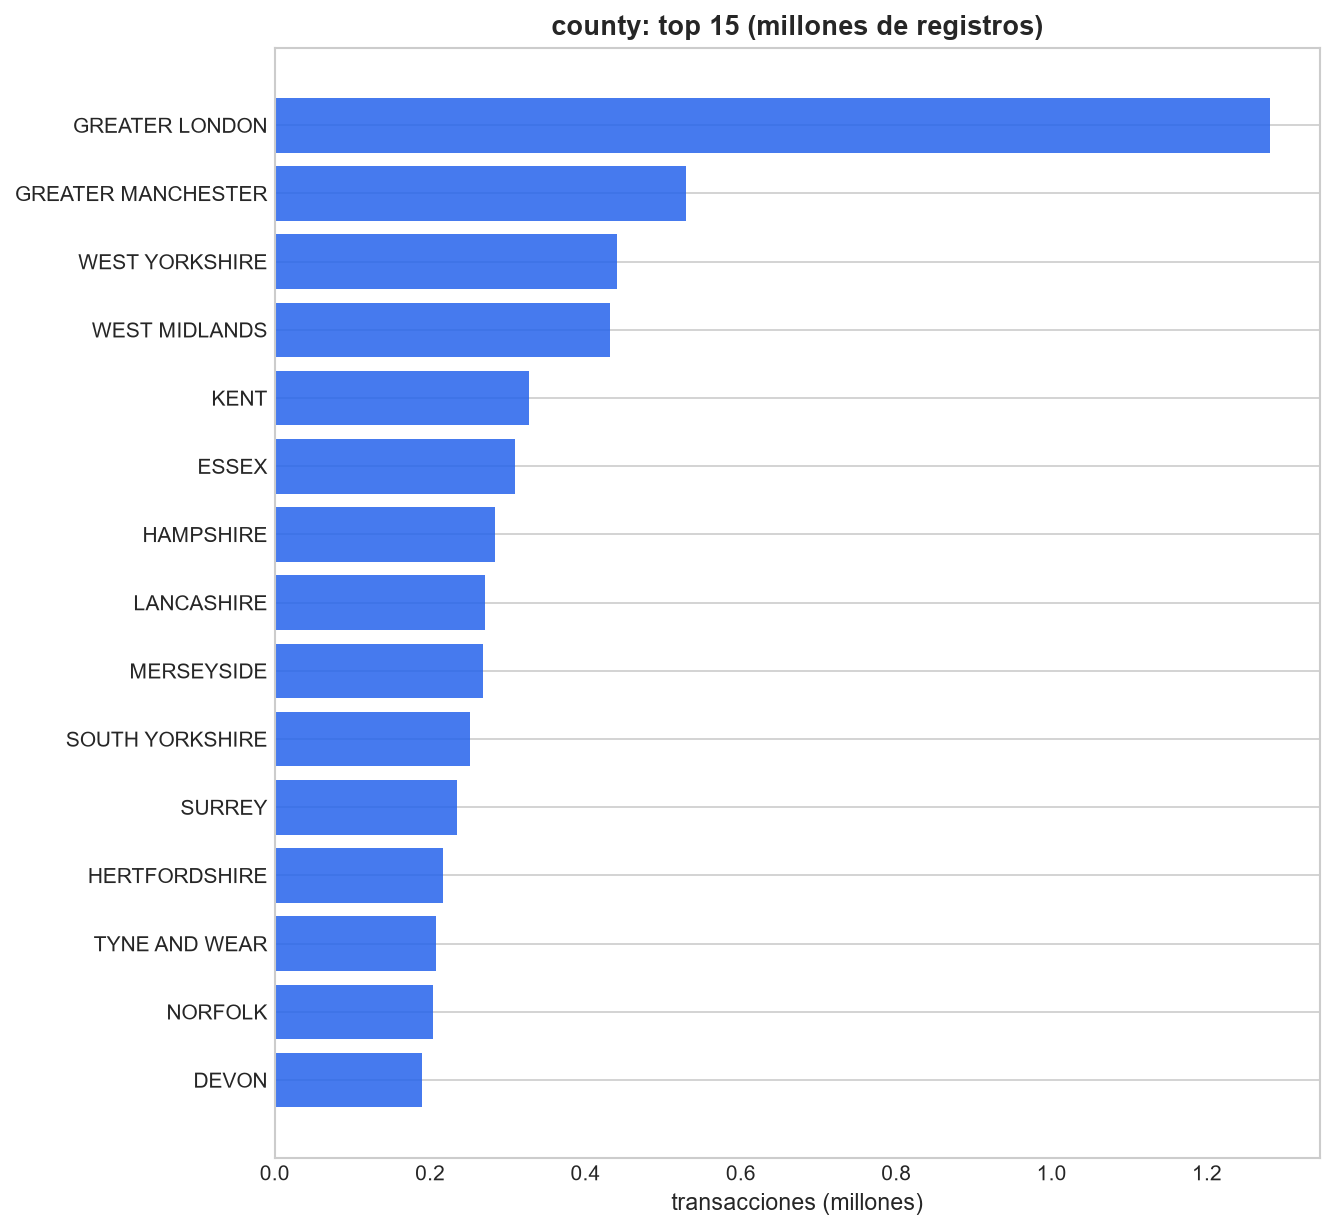

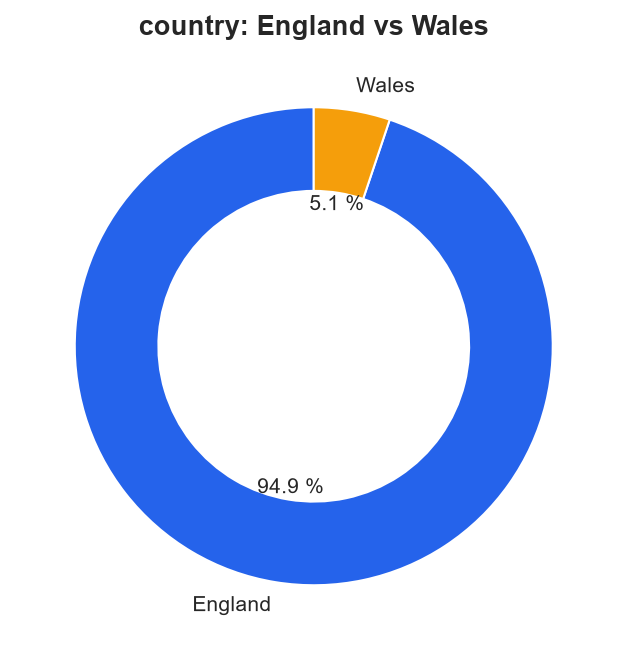

In [8]:
graficos.presentar(graficos.top_categorias(df, 'town_city', 10))
graficos.presentar(graficos.top_categorias(df, 'county', 15))
graficos.presentar(graficos.pais_donut(df))

## 7. Outliers en `price`: qué datos manejamos

Antes de la regla, fijamos **qué datos entran a este análisis**:

| Columna | Rol | Valores |
|---|---|---|
| `price` | **Variable objetivo**: precio efectivo de la transacción (GBP) | £100 .. £900.000.000 |
| `latitude` / `longitude` | Georreferenciación del inmueble | 51,3 .. 53,5 · −4,8 .. 1,6 |
| `town_city` / `county` / `country` | Ubicación administrativa | 1.153 / 117 / 2 |

De ellas, la **única numérica continua** es `price`; los atípicos se evalúan solo sobre ella.

**Los 4 cuartiles de `price` y por qué Q1 + Q2 son los de mayor uso**

Dividir los datos en 4 partes iguales da los cuartiles **Q1, Q2, Q3 y Q4**; cada uno contiene ~25 % de las transacciones. La columna analizada es `price` (variable objetivo).

En el mercado inmobiliario la masa cae en los **cuartiles bajos**: **Q1 + Q2 (50 % de la base) viven por debajo de la mediana (250.000 £)** — es la vivienda típica. La referencia central es por eso la **mediana (Q2)** y no la media (contaminada por el máximo de £900M, a z ≈ 591). El IQR (Tukey) se apoya en **Q1 y Q3** como anclas y recorta la cola extrema del Q4. Cálculo con los valores reales:

,cuartil,rango (GBP),transacciones,% datos
0,Q1,"100 .. 158,000",2829513,24.89
1,Q2,"158,000 .. 250,000",2844886,25.02
2,Q3,"250,000 .. 385,000",2815764,24.77
3,Q4,"385,000 .. 900,000,000",2879250,25.32


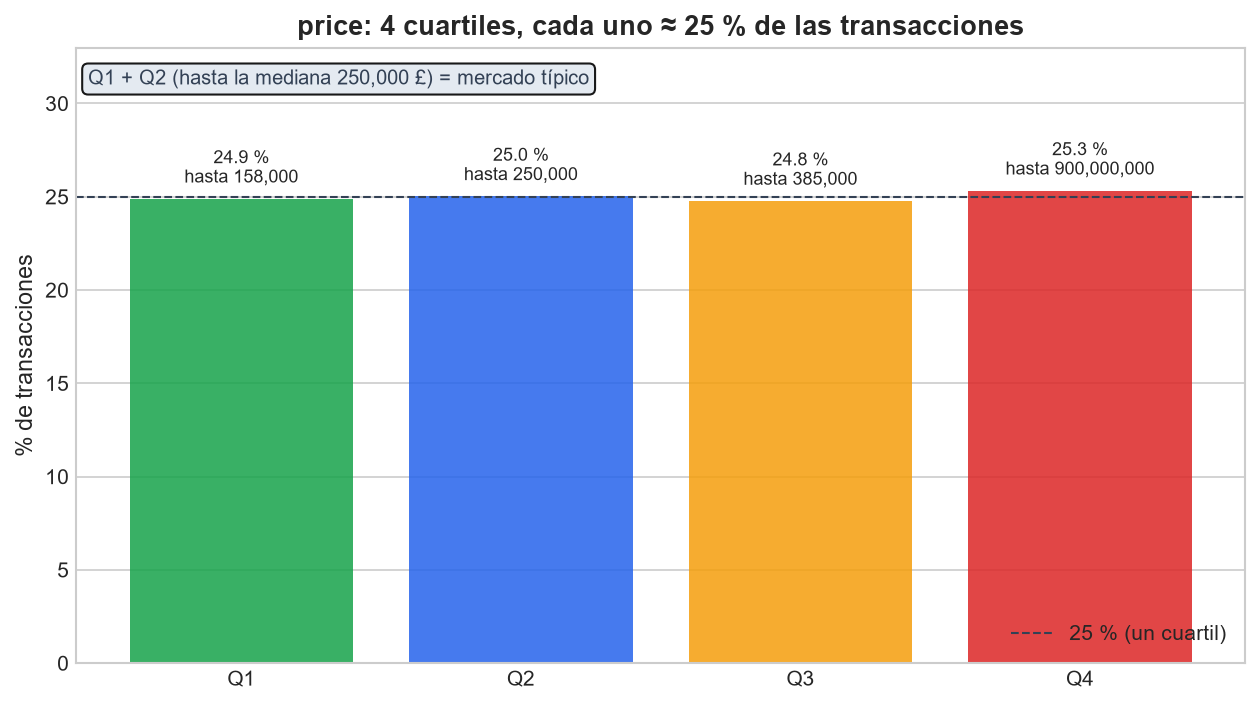

PASO 1   ordenar los 11,369,413 valores de price
PASO 2   cuartiles de corte: Q1 = 158,000 · Q2 mediana = 250,000 · Q3 = 385,000
PASO 3   IQR = Q3 - Q1 = 227,000
PASO 4   limite inferior = -182,500 · limite superior = 725,500
PASO 5   fuera de limites = 718,461 (6.32 % de la base)
PASO 6   decision: winsorizar al limite superior 725,500


In [9]:
price = df['price'].astype('float64')

# 1) cuadro: los 4 cuartiles de price (rango, transacciones, % del total)
cuartiles_tabla = diag.tabla_cuartiles(price)
display(cuartiles_tabla)

# 2) grafica: cada cuartil pesa ~25 %; Q1 + Q2 = mercado tipico
graficos.presentar(graficos.cuartiles_barras(cuartiles_tabla, price.median()))

# 3) IQR paso a paso (Tukey: 1,5 x IQR)
lim = diag.limites_iqr(price)
print('PASO 1   ordenar los', f"{len(price):,}", 'valores de price')
print(f"PASO 2   cuartiles de corte: Q1 = {lim['q1']:,.0f} · Q2 mediana = {lim['q2']:,.0f} · Q3 = {lim['q3']:,.0f}")
print(f"PASO 3   IQR = Q3 - Q1 = {lim['iqr']:,.0f}")
print(f"PASO 4   limite inferior = {lim['limite_inferior']:,.0f} · limite superior = {lim['limite_superior']:,.0f}")
fuera = diag.contar_fuera_de_iqr(price, lim)
print(f"PASO 5   fuera de limites = {fuera:,} ({100 * fuera / len(price):.2f} % de la base)")
print(f"PASO 6   decision: winsorizar al limite superior {lim['limite_superior']:,.0f}")

**Gráfico: distribución de `price` con los tres cuartiles y el límite IQR**

El histograma (escala log) completa el cuadro: **Q1, la mediana (Q2) y Q3** marcan la zona donde vive el 75 % del mercado (Q1 + Q2 + Q3) y el límite IQR muestra cuánto pesa la cola derecha del Q4 (6,32 % fuera):

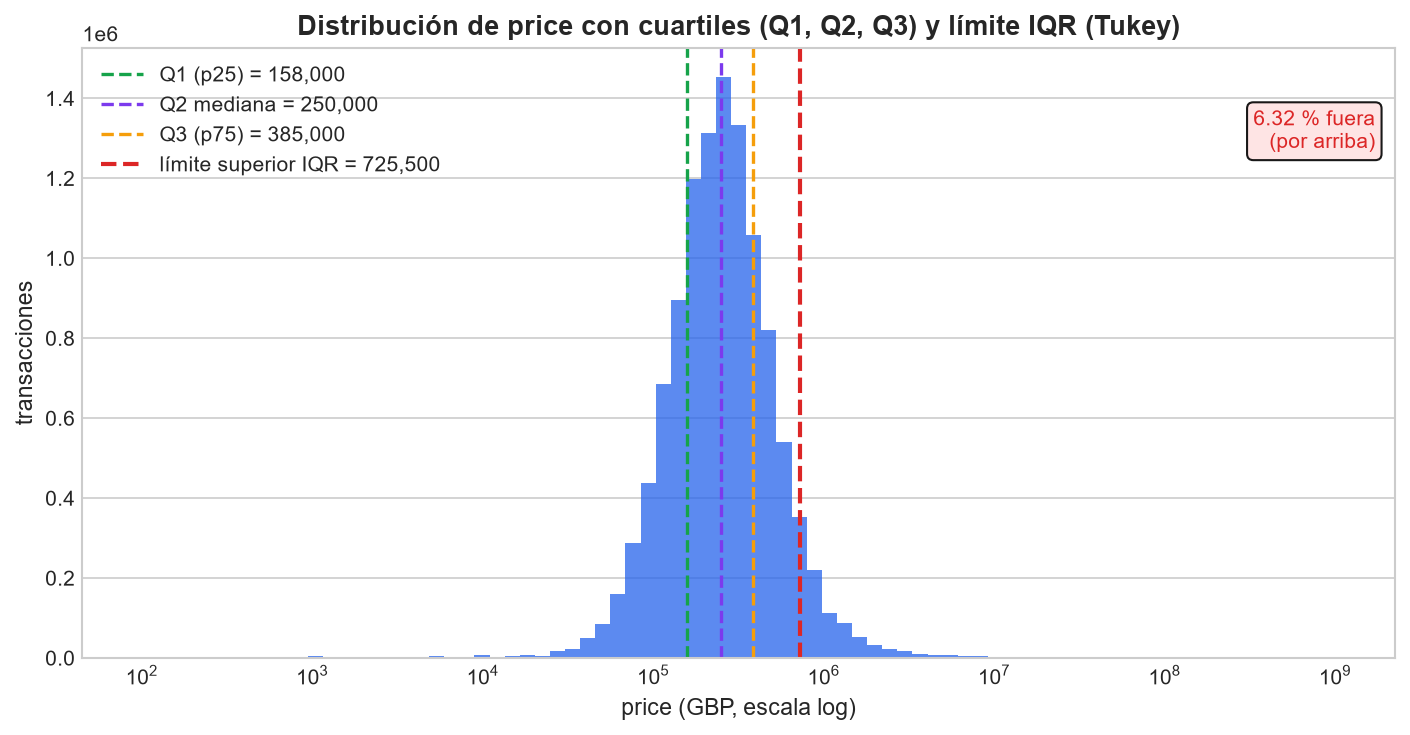

In [10]:
graficos.presentar(graficos.hist_price_iqr(price, lim))

**Antes / después de la decisión**: el boxplot compara `price` original vs winsorizado mientras el histograma anterior mostraba la cola derecha después del límite:

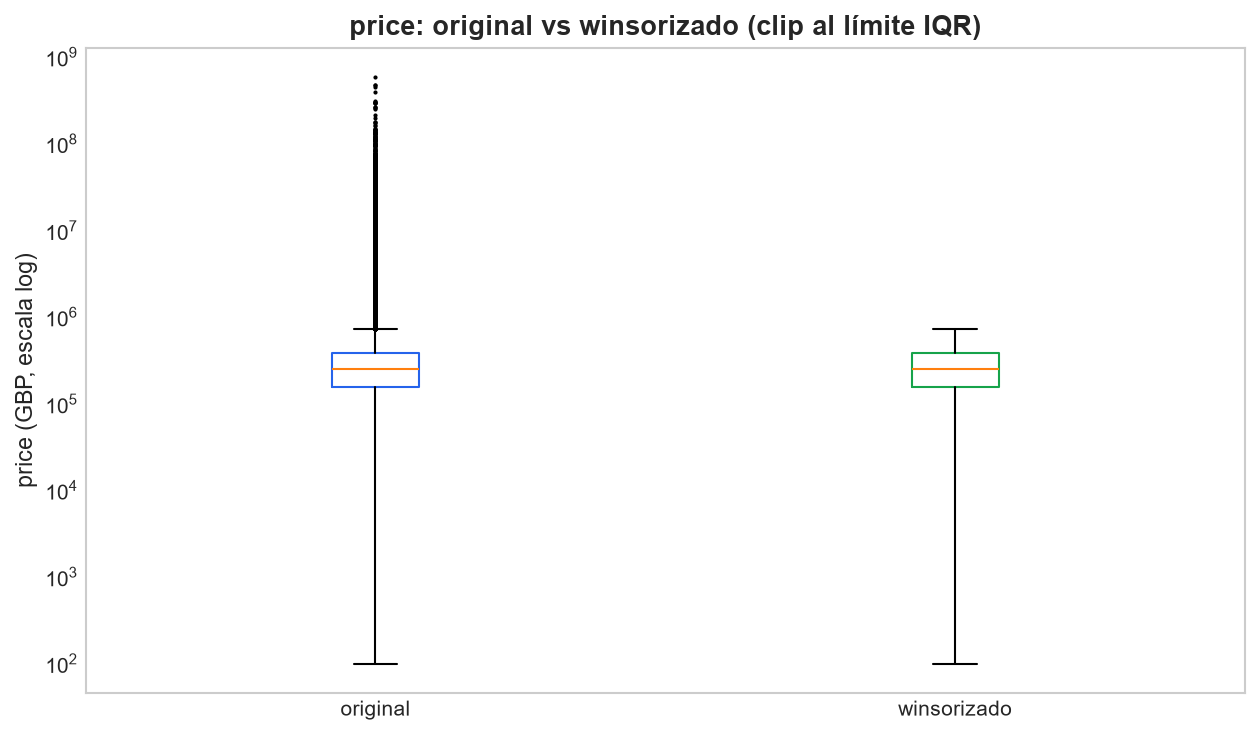

In [11]:
winsorizado = transformaciones.winsorizar_price(price, lim['limite_superior'])
graficos.presentar(graficos.box_antes_despues(price, winsorizado))

**Tratar vs conservar (decisión de negocio)**

718.461 filas (6,32 %) quedan fuera, **todas por arriba** (el límite inferior es negativo e irrelevante). El outlier puede ser error **o** señal: una casa de £900M es verificablemente real (valor extremo del mercado = señal que normalmente se conserva).

Sin embargo, como `price` **entra a un modelo predictivo**, un máximo 900M rompería cualquier escalado → se **trata** con **winsorizar** (`clip`): se conserva la fila y se recorta el valor al límite superior, como en TelecomUNO con `gb_datos`. La decisión queda registrada en bitácora.

## 8. Fechas y columnas derivadas

Rango del periodo, fechas futuras y consistencia de `year/month/quarter`.

In [12]:
fechas = diag.analizar_fechas(df)
print('fecha min/max:', fechas['min'], '/', fechas['max'])
print('fechas futuras (>2026):', fechas['futuras'])
print('inconsistencias year/month/quarter vs date:', fechas['incoherencias_derivadas'])

fecha min/max: 2015-01-01 00:00:00 / 2026-06-30 00:00:00
fechas futuras (>2026): 0
inconsistencias year/month/quarter vs date: 0


**Lectura**: periodo **2015-01-01 → 2026-06-30**, 0 futuras y 0 inconsistencias. Las derivadas son coherentes y se conservan. El gráfico combina volumen y mediana de `price` por año:

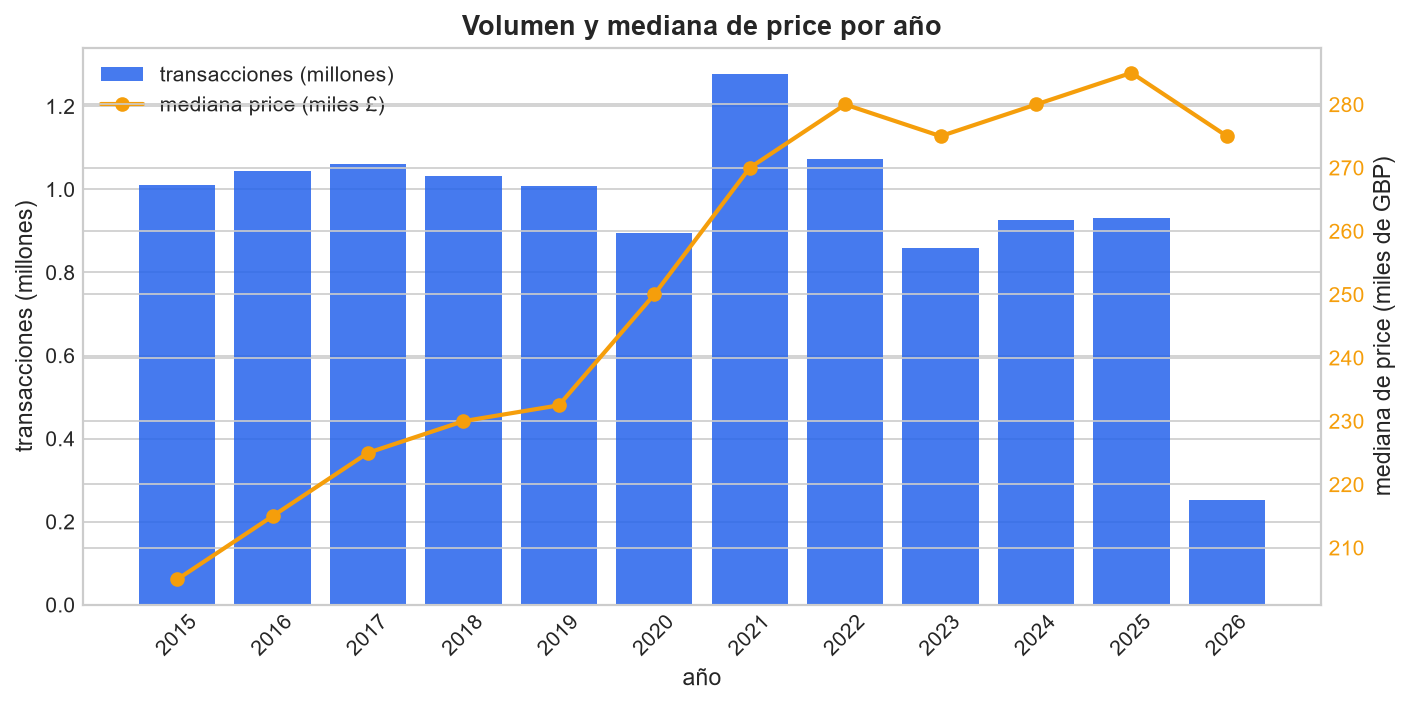

In [13]:
graficos.presentar(graficos.temporal_price(df))

## 9. Resumen de problemas encontrados

| # | Columna | Problema | Cantidad | % | Clasificación | Tratamiento |
|---|---|---|---|---|---|---|
| 1 | `price` | Atípicos (IQR) | 718.461 | 6,32 % | Cola derecha real del mercado | Winsorizar (clip) + bandera `es_atipico_precio` |
| 2 | geo (5 cols) | Nulos simultáneos | 22.913 | 0,20 % | **MCAR** de geocodificación | Bandera `es_sin_geo`; no imputar |
| 3 | `transaction_id` | Duplicados | 0 | 0 % | Ninguno | Verificar |
| 4 | `town_city`/`county`/`country` | Colisiones de escritura | 0 | 0 % | Ninguna (ya normalizadas) | Conservar |
| 5 | `year`/`month`/`quarter` | Inconsistencia vs fecha | 0 | 0 % | Ninguna | Conservar |
| 6 | fechas | Futuras | 0 | 0 % | Ninguna | — |

## 10. Implementación de la limpieza

Sobre una copia (`limpio`): banda de MCAR geo y winsorización del precio, con cada transformación registrada en la **bitácora** (qué cambió, cuántos valores, con qué criterio). Ninguna fila se elimina.

In [14]:
bitacora = Bitacora()
limpio = transformaciones.crear_bandera_sin_geo(df, bitacora)
limpio = transformaciones.aplicar_bandera_atipicos(limpio, price, lim, bitacora)

print('shape: original -> limpio', df.shape, '->', limpio.shape)
print('price tras clip min/max:', limpio['price'].min(), '/', limpio['price'].max())

shape: original -> limpio (11369413, 20) -> (11369413, 22)
price tras clip min/max: 100 / 725500


## 11. Validación final (post-limpieza)

Los criterios se comparan contra las cifras verificadas; un `assert` corta si algo no cuadra (nivel Excepcional del curso: pruebas automáticas de validación).

In [15]:
criterios = validacion.construir_criterios(limpio)
display(criterios)
validacion.validar_criterios(criterios)

,criterio,real,esperado
0,duplicados exactos,0,0
1,duplicados por transaction_id,0,0
2,nulos en criticas,0,0
3,fechas futuras,0,0
4,filas es_sin_geo,22913,22913
5,filas es_atipico_precio,718461,718461
6,price minimo,100,100
7,price maximo,725500,725500


VALIDACION OK: todos los criterios en verde


## 12. Bitácora de decisiones

Evidencia del entregable: cada corrección con su método, razón e impacto.

In [16]:
display(bitacora.tabla())

,columna,problema,cantidad,metodo,razon,impacto
0,lat/long/region/country/admin_district,nulos geo (MCAR),22913,bandera es_sin_geo,ausencia de geocodificacion; inventar coordena...,"22,913 filas marcadas, 0 eliminadas"
1,price,valores atipicos (IQR),718461,winsorizar (clip) + bandera es_atipico_precio,"6,32 % por arriba; price entra a un modelo pre...","718,461 filas ajustadas al limite, 0 eliminadas"


## 13. Dataset limpio

Exportación preparada (parquet, única salida); se activa cuando el equipo lo decida. Las cifras de este cuaderno se recalculan **en vivo**, sin valores inventados.

In [17]:
# DESTINO = config.RUTA_SALIDA
# limpio.to_parquet(DESTINO, index=False)
# print('version limpia exportada:', DESTINO)

## Notas finales

- Dataset limpio con **22 columnas** = 20 originales + `es_sin_geo` + `es_atipico_precio`.
- **Ninguna fila se eliminó**; los problemas son de nulos geo **MCAR** (bandera) y de atípicos de `price` (winsorizar), ambos documentados en bitácora.
- `price` queda preparado como **variable objetivo** con la cola recortada al límite IQR.
- Siguientes pasos: transformación y reducción — escalado, one-hot, PCA.
- Referencia: `presentacion.html` y `codigo/limpieza_telecom.py` del curso.